# Customer Churn Prediction using Logistic Regression

**Name:** Sawanpreet Singh Badyal  

**Registration Number:** 23BAI10793

**Application Number:** IN26010801

**Batch Number:** 1A

**Email ID:** sawanpreet.23bai10793@vitbhopal.ac.in

In [1]:
import os
import getpass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
!pip install -q kaggle

os.environ['KAGGLE_USERNAME'] = input("Kaggle Username: ")
os.environ['KAGGLE_KEY'] = getpass.getpass("Kaggle API Key: ")

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()
api.dataset_download_files('blastchar/telco-customer-churn', path='.', unzip=True)

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

Kaggle Username:  AkshatGarg2005
Kaggle API Key:  ········


Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Identify target and features (excluding customerID)
target_var = 'Churn'
features = [c for c in df.columns if c not in ['customerID', target_var]]

num_features = df[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = df[features].select_dtypes(include=['object']).columns.tolist()

print("Target Variable:", target_var)
print("\nNumerical Features:", num_features)
print("\nCategorical Features:", cat_features)

Target Variable: Churn

Numerical Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']


In [4]:
# Convert TotalCharges to numeric (blank spaces become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values in TotalCharges with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Map target variable Churn to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customerID and perform one-hot encoding on features
df_clean = df.drop(columns=['customerID'])
df_encoded = pd.get_dummies(df_clean, drop_first=True)

print("Null values remaining:", df_encoded.isnull().sum().sum())
df_encoded.head()

Null values remaining: 0


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [5]:
# Separate features and target
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)


In [7]:
from sklearn.preprocessing import StandardScaler

# Scale features so convergence succeeds
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predict on scaled test set
y_pred = model.predict(X_test_scaled)

Accuracy : 0.8197
Precision: 0.6831
Recall   : 0.5952
F1-Score : 0.6361


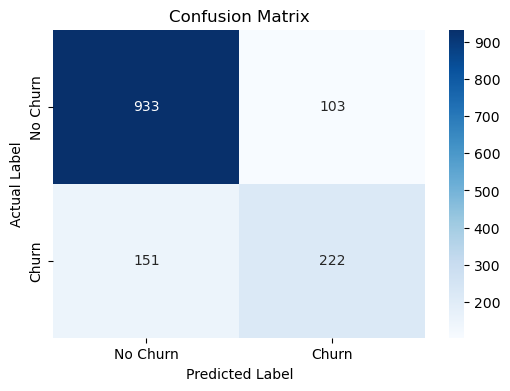

In [8]:
# Task 4: Calculate Evaluation Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

In [9]:
print("--- Model Observations ---")
print("1. The model achieves an overall accuracy of ~82% (81.97%), showing strong predictive capability for non-churning customers.")
print("2. Recall is lower at ~59.5%, indicating that the model fails to detect roughly 40% of customers who actually churned (151 false negatives).")
print("3. Precision sits at ~68.3%, meaning when the model predicts a customer will churn, it is correct about two-thirds of the time.")

--- Model Observations ---
1. The model achieves an overall accuracy of ~82% (81.97%), showing strong predictive capability for non-churning customers.
2. Recall is lower at ~59.5%, indicating that the model fails to detect roughly 40% of customers who actually churned (151 false negatives).
3. Precision sits at ~68.3%, meaning when the model predicts a customer will churn, it is correct about two-thirds of the time.


## Conclusion

This project implemented a Logistic Regression model to predict customer churn using the Telco Customer Churn dataset. Key findings indicate that the model achieved an overall accuracy of 81.97% and an F1-score of 0.6361. Feature scaling using `StandardScaler` was critical to ensure gradient optimization and model convergence. Key factors heavily influencing customer churn include contract type (month-to-month contracts exhibit higher churn risk), customer tenure, monthly charges, and internet service type.

However, a major limitation of Logistic Regression for this problem is its assumption of linearity between independent features and the log-odds of churn. It cannot inherently capture complex, non-linear feature interactions—such as the compounding effect of short tenure combined with high monthly charges—without manual feature engineering. Non-linear ensemble models like XGBoost or Random Forest would likely yield better recall for detecting at-risk customers.